In [1]:
import numpy as np
from sklearn.metrics import accuracy_score
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV, FrozenEstimator
from metrics import compute_model_output_metrics
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBClassifier

In [2]:
sns.set_theme(style='darkgrid')
sns.set_context('paper')

In [3]:
X_train, y_train = np.load('train_x.npy'), np.load('train_y.npy')
X_test, y_test = np.load('test_x.npy'), np.load('test_y.npy')

In [4]:
def describe_model(model):
    y_preds = model.predict(X_test)
    probs = model.predict_proba(X_test)
    stats = compute_model_output_metrics(y_test, y_preds, probs)
    print(f'Accuracy: {round(stats['acc'] * 100, 2)}%')
    print(f'Expected Calibration Error: {round(stats['ece'] * 100, 2)}%')
    print(f'Spread: {round(stats['spread'], 4)}')
    print(f'Binary Cross Entropy Loss: {round(stats['bce'], 4)}')
    plt.figure(figsize=(8, 5))
    sns.histplot(x=probs[:, 0], kde=True, bins=20)
    plt.xlabel('Probability')
    plt.title('Estimated Win Probability Frequencies')
    plt.show()

In [13]:
lr_model = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression())
])

In [14]:
lr_model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('logreg', LogisticRegression())])

Accuracy: 72.57%
Expected Calibration Error: 0.76%
Spread: 0.2784
Binary Cross Entropy Loss: 0.5135


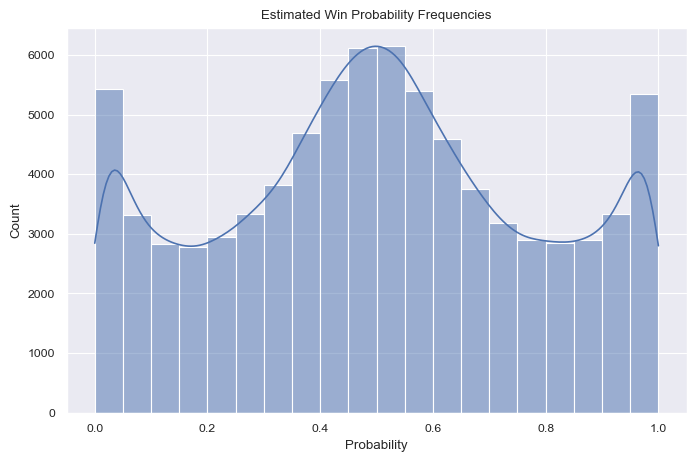

In [20]:
describe_model(lr_model)

In [16]:
mlp = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(64),
        activation="relu",
        solver="adam",
        alpha=1e-4,
        batch_size=32,
        learning_rate_init=1e-3,
        max_iter=300,
        early_stopping=True,
        random_state=42
    ))
])

In [17]:
calibrated_mlp = CalibratedClassifierCV(
    estimator=mlp,
    method="isotonic",
    cv=5,
)

In [18]:
calibrated_mlp.fit(X_train, y_train)

C:\Users\fahd3\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:698: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


KeyboardInterrupt: 

In [ ]:
describe_model(calibrated_mlp)

In [19]:
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    eval_metric="logloss",
    random_state=42
)

In [20]:
xgb_calibrated = CalibratedClassifierCV(
    estimator=xgb,
    method="isotonic",
    cv=5
)

In [21]:
xgb_calibrated.fit(X_train, y_train)

CalibratedClassifierCV(cv=5,
                       estimator=XGBClassifier(base_score=None, booster=None,
                                               callbacks=None,
                                               colsample_bylevel=None,
                                               colsample_bynode=None,
                                               colsample_bytree=None,
                                               device=None,
                                               early_stopping_rounds=None,
                                               enable_categorical=False,
                                               eval_metric='logloss',
                                               feature_types=None,
                                               feature_weights=None, gamma=None,
                                               grow_policy=None,
                                               importance_type=None,
                                               interaction_constraints=None,
                                               learning_rate=0.1, max_bin=None,
                                               max_cat_threshold=None,
                                               max_cat_to_onehot=None,
                                               max_delta_step=None, max_depth=6,
                                               max_leaves=None,
                                               min_child_weight=None,
                                               missing=nan,
                                               monotone_constraints=None,
                                               multi_strategy=None,
                                               n_estimators=200, n_jobs=None,
                                               num_parallel_tree=None, ...),
                       method='isotonic')

Accuracy: 71.72%
Expected Calibration Error: 0.29%
Spread: 0.2644
Binary Cross Entropy Loss: 0.5271


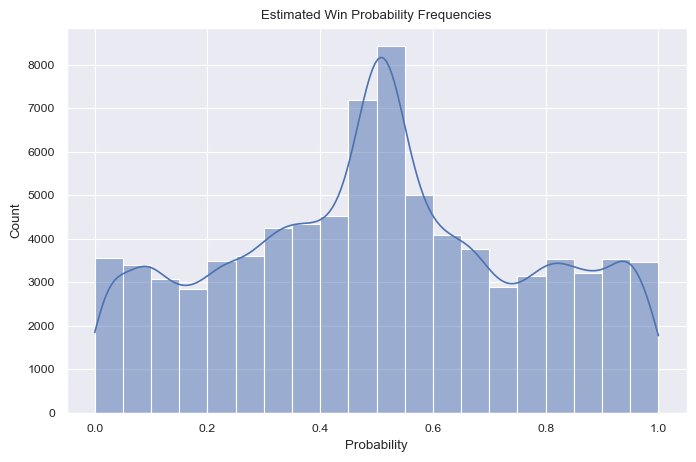

In [24]:
describe_model(xgb_calibrated)

In [19]:
import joblib
joblib.dump(lr_model, 'model.pkl')

['model.pkl']